In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_json("../datas/commandes_raw.json")
df_raw.head()
df_raw.info()
df_raw.describe()

df_raw.shape


<class 'pandas.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   commande_id            937 non-null    str    
 1   client_id              934 non-null    str    
 2   ville_livraison        938 non-null    str    
 3   date_commande          1026 non-null   str    
 4   date_livraison_prevue  939 non-null    str    
 5   date_livraison_reelle  926 non-null    str    
 6   poids_kg               1025 non-null   float64
 7   transporteur           918 non-null    str    
 8   distance_km            1026 non-null   float64
 9   nb_articles            1026 non-null   int64  
 10  statut                 1026 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 182.4 KB


(1026, 11)

In [3]:
print(f"nombre de duplicate: {df_raw.duplicated().sum()}")
print(f"valeur manquantes par colonnes:\n{df_raw.isna().sum(axis=0)}")


nombre de duplicate: 24
valeur manquantes par colonnes:
commande_id               89
client_id                 92
ville_livraison           88
date_commande              0
date_livraison_prevue     87
date_livraison_reelle    100
poids_kg                   1
transporteur             108
distance_km                0
nb_articles                0
statut                     0
dtype: int64


In [4]:
#incohérences dates
def check_dates(dt_cmd, dt_liv_prev, df_liv_rel):
    incoherence = 0
    if pd.to_datetime(dt_cmd) > pd.to_datetime(dt_liv_prev) or pd.to_datetime(dt_cmd) > pd.to_datetime(df_liv_rel) :
        incoherence = 1
        
    return incoherence

df_raw["incoherence"] = df_raw[["date_commande", "date_livraison_prevue", "date_livraison_reelle" ]].apply(lambda r: check_dates(r["date_commande"],r["date_livraison_prevue"],r["date_livraison_reelle"]), axis=1)

df_raw["incoherence"] = (
    (df_raw["date_commande"] > df_raw["date_livraison_prevue"]) |
    (df_raw["date_commande"] > df_raw["date_livraison_reelle"])
)
print(df_raw["incoherence"])
print(df_raw["incoherence"].sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1021    False
1022    False
1023    False
1024    False
1025    False
Name: incoherence, Length: 1026, dtype: bool
0


<Axes: ylabel='poids_kg'>

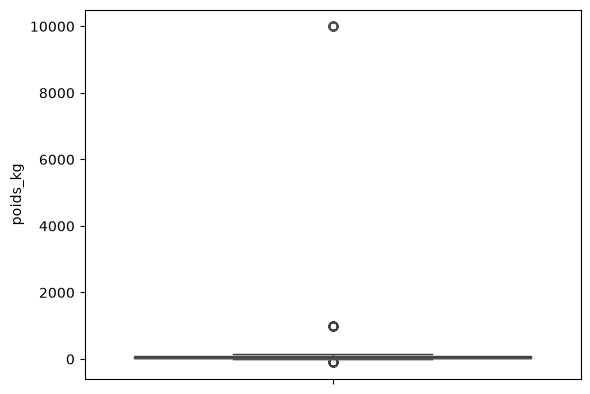

In [13]:
# poids negatif
sns.boxplot(df_raw.poids_kg)
sns.boxplot(df_raw.distance_km)
#sns.boxplot(df_raw.nb_articles)

              nb_jour_retard
transporteur                
ColisExpress      160.297872
DDPP              109.322034
KKExpress         146.577586
LaBP              113.413462
LivrHome           98.130841


<BarContainer object of 7 artists>

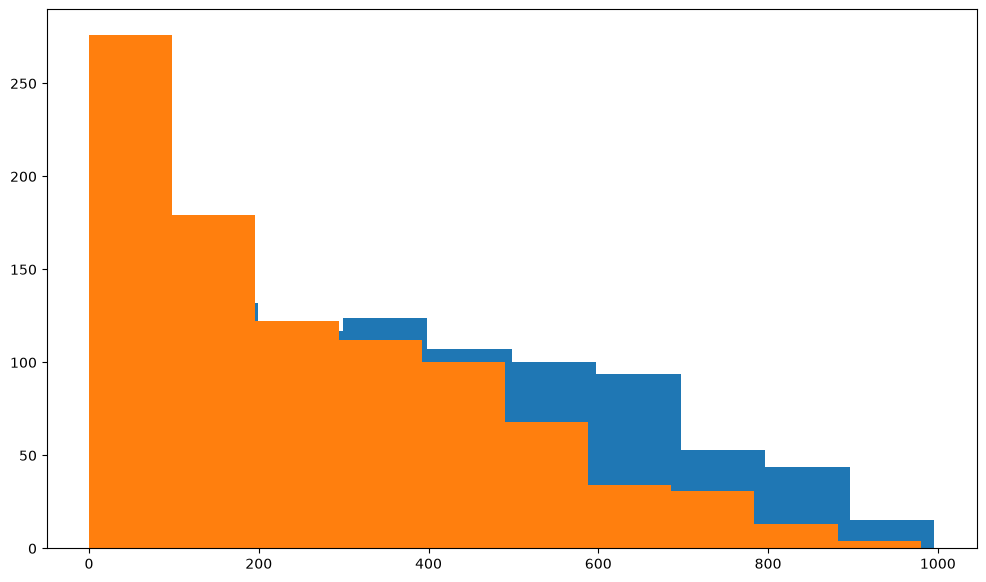

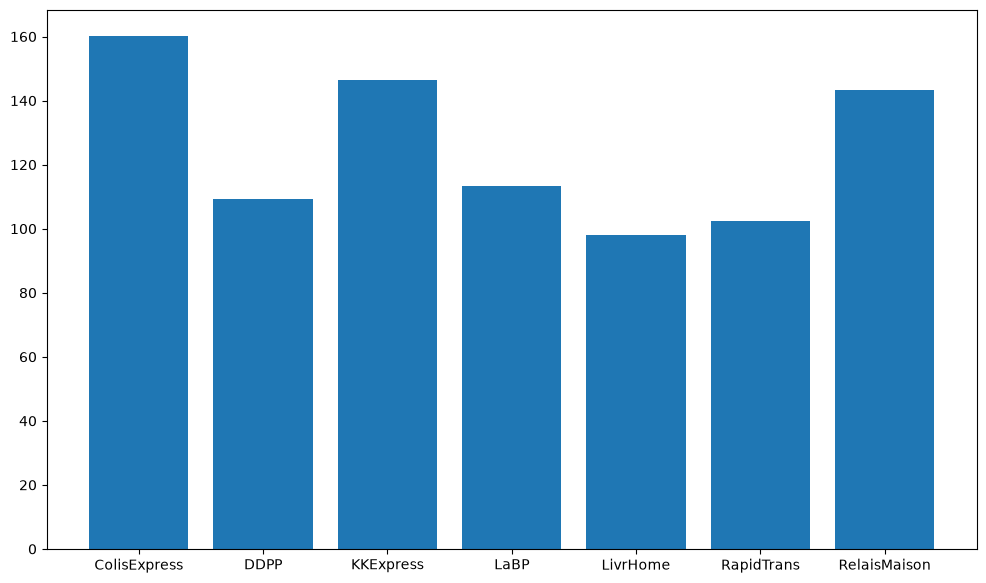

In [6]:
# distribution delais de livraison reel
df_raw["nb_jour_rel"] = (pd.to_datetime(df_raw.date_livraison_reelle)-pd.to_datetime(df_raw.date_commande) ).dt.days
df_raw["nb_jour_prev"] = ( pd.to_datetime(df_raw.date_livraison_prevue)-pd.to_datetime(df_raw.date_commande) ).dt.days

df_raw["nb_jour_retard"]= (pd.to_datetime(df_raw.date_livraison_reelle) - pd.to_datetime(df_raw.date_livraison_prevue) ).dt.days
df_transp = df_raw[["nb_jour_retard","transporteur"]].groupby(by=["transporteur"]).mean()
plt.figure(figsize=(12,7))
plt.hist(df_raw["nb_jour_rel"] )
plt.hist(df_raw["nb_jour_prev"] )

print(df_transp.head())
plt.figure(figsize=(12,7))
plt.bar(df_transp.index, df_transp["nb_jour_retard"] )




Text(0.5, 1.0, 'Evolution')

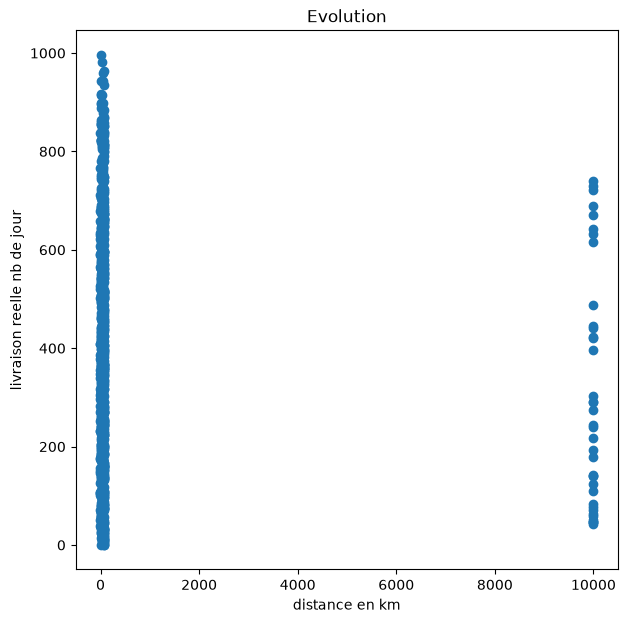

In [9]:
plt.figure(figsize=(7,7))
plt.scatter(df_raw.distance_km, df_raw.nb_jour_rel)
plt.xlabel("distance en km")
plt.ylabel("livraison reelle nb de jour")
plt.title("Evolution")